In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sonal9425/toxic-content-classification/processed_data.csv


In [2]:
#imports
import pandas as pd
import numpy as np
from scipy.sparse import hstack
import os
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.multiclass import OneVsRestClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

In [3]:
import os
import pandas as pd

BASE_PATH = "/kaggle/input/datasets/sonal9425/toxic-content-classification"

print(os.listdir(BASE_PATH))  # check files

df = pd.read_csv(f"{BASE_PATH}/processed_data.csv")  # use real name

df.head()

['processed_data.csv']


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,clean_text,processed_text,...,question_count,digit_count,caps_ratio,toxic_word_count,toxic_word_ratio,avg_word_length,unique_word_ratio,sentiment,label_count,clean
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,explanation why the edits made under my userna...,explanation edit username hardcore metallica f...,...,1,9,0.064151,0,0.0,6.000000,0.931818,0.136364,0,True
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,daww he matches this background colour im seem...,daww match background colour m seemingly stuck...,...,0,10,0.070796,0,0.0,6.222222,0.944444,0.287500,0,True
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,hey man im really not trying to edit war its j...,hey man m not try edit war guy constantly remo...,...,0,0,0.017094,0,0.0,5.418605,0.906977,0.160000,0,True
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,more i cant make any real suggestions on impro...,not real suggestion improvement wonder section...,...,0,0,0.017657,0,0.0,5.456140,0.719298,0.200000,0,True
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,you sir are my hero any chance you remember wh...,sir hero chance remember page s,...,1,0,0.029412,0,0.0,4.785714,0.928571,0.000000,0,True


In [4]:
import torch

# Check if CUDA (GPU) is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CPU


In [5]:
# Check GPU memory usage if a GPU is available
if torch.cuda.is_available():
    print(f"Allocated GPU memory: {torch.cuda.memory_allocated(device) / 1024**2:.2f} MB")
    print(f"Cached GPU memory: {torch.cuda.memory_reserved(device) / 1024**2:.2f} MB")

In [6]:
# Fix missing text
df["processed_text"] = df["processed_text"].fillna("")
df = df[df["processed_text"].str.strip() != ""]

In [7]:
# Features & Labels
X = df["processed_text"]

y = df[
    [
        "toxic",
        "severe_toxic",
        "obscene",
        "threat",
        "insult",
        "identity_hate"
    ]
]
labels = y.columns.tolist()

print("Dataset Shape:", df.shape)

Dataset Shape: (159443, 25)


In [8]:
# 2. TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Samples:", len(X_train))
print("Test Samples:", len(X_test))

Train Samples: 127554
Test Samples: 31889


In [9]:
# 3. TF-IDF
# ==============================

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

print("\nCreating TF-IDF Features...")

# Word TF-IDF
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

# Character TF-IDF
char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=5000
)

# Word Features
X_train_word = tfidf.fit_transform(X_train)
X_test_word = tfidf.transform(X_test)

# Character Features
X_train_char = char_tfidf.fit_transform(X_train)
X_test_char = char_tfidf.transform(X_test)

# Combine Features
X_train_tfidf = hstack([
    X_train_word,
    X_train_char
])

X_test_tfidf = hstack([
    X_test_word,
    X_test_char
])

print("Word Shape:", X_train_word.shape)
print("Character Shape:", X_train_char.shape)
print("Combined Shape:", X_train_tfidf.shape)


Creating TF-IDF Features...
Word Shape: (127554, 30000)
Character Shape: (127554, 5000)
Combined Shape: (127554, 35000)


In [10]:
# =====================================================
# 4. LOGISTIC REGRESSION MODEL
# =====================================================

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

lr_model = OneVsRestClassifier(
    LogisticRegression(
        C=0.25,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

print("Training Complete!")

Training Complete!


In [11]:
# 5. PREDICT PROBABILITIES

y_prob_lr = lr_model.predict_proba(
    X_test_tfidf
)
print("\nPrediction Probabilities Generated!")


Prediction Probabilities Generated!


In [12]:
# 6. AUTO THRESHOLD TUNING
# =====================================================

from sklearn.metrics import f1_score

print("\nFinding Optimal Thresholds...")

optimal_thresholds = []

for i in range(len(labels)):

    best_threshold = 0.5
    best_f1 = 0

    for threshold in np.arange(0.2, 0.9, 0.05):

        pred = (
            y_prob_lr[:, i] > threshold
        ).astype(int)

        score = f1_score(
            y_test.iloc[:, i],
            pred,
            zero_division=0
        )

        if score > best_f1:
            best_f1 = score
            best_threshold = threshold

    optimal_thresholds.append(
        best_threshold
    )

optimal_thresholds = np.array(
    optimal_thresholds
)

print("\nOptimal Thresholds:")

for label, thr in zip(
    labels,
    optimal_thresholds
):
    print(
        f"{label}: {thr:.2f}"
    )
 



Finding Optimal Thresholds...

Optimal Thresholds:
toxic: 0.75
severe_toxic: 0.85
obscene: 0.80
threat: 0.85
insult: 0.80
identity_hate: 0.85


In [13]:
# APPLY OPTIMAL THRESHOLDS
# =====================================================

y_pred_lr = np.zeros_like(
    y_prob_lr
)

for i in range(len(labels)):

    y_pred_lr[:, i] = (
        y_prob_lr[:, i]
        > optimal_thresholds[i]
    ).astype(int)

In [14]:
# 7. EVALUATION
# =====================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_lr,
        zero_division=0
    )
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_lr,
    average="macro"
)

print(f"\nMacro ROC-AUC Score: {roc_auc:.4f}")

from sklearn.metrics import hamming_loss
from sklearn.metrics import jaccard_score

print(
    "\nHamming Loss:",
    hamming_loss(y_test, y_pred_lr)
    )

print(
    "Jaccard Score:",
    jaccard_score(
        y_test,
        y_pred_lr,
        average='samples'
    )
)


Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.74      0.78      3027
           1       0.37      0.81      0.51       317
           2       0.83      0.81      0.82      1671
           3       0.31      0.60      0.41        93
           4       0.70      0.74      0.72      1559
           5       0.41      0.69      0.52       295

   micro avg       0.71      0.76      0.74      6962
   macro avg       0.57      0.73      0.63      6962
weighted avg       0.75      0.76      0.75      6962
 samples avg       0.06      0.07      0.06      6962


Macro ROC-AUC Score: 0.9845

Hamming Loss: 0.01986578443977547
Jaccard Score: 0.053949115159877485


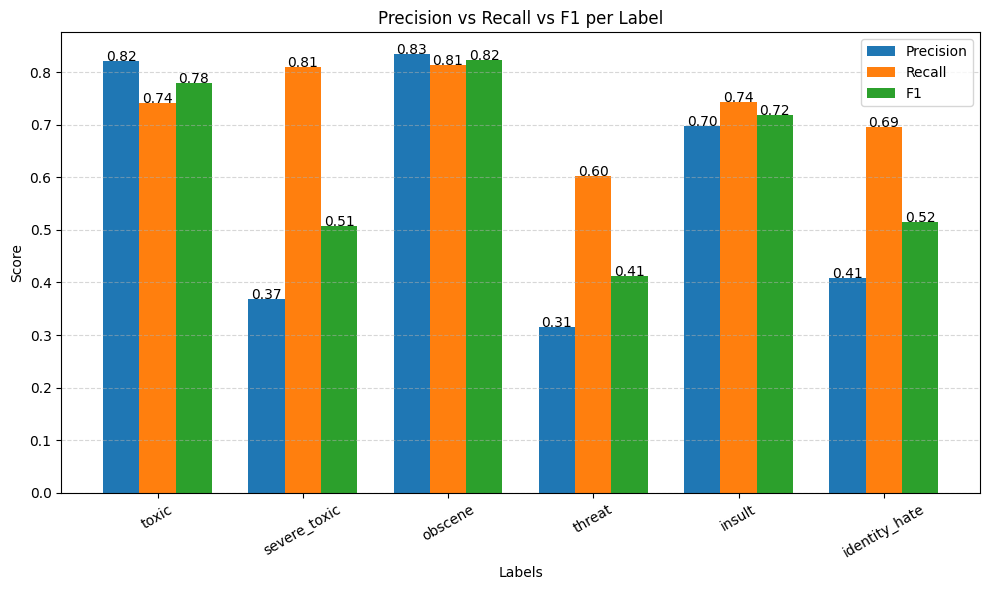

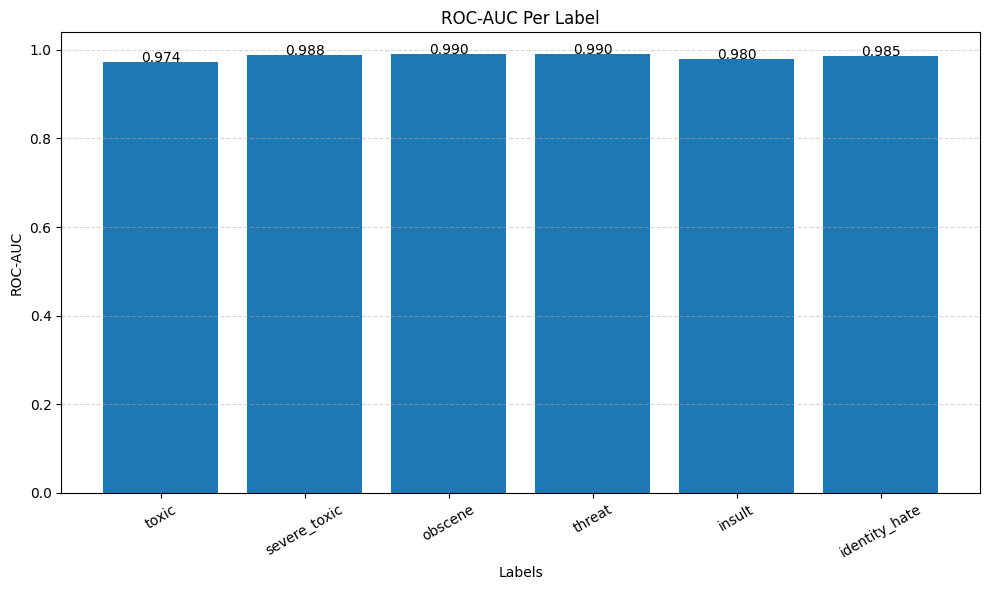

In [15]:
# Precision vs Recall vs F1 per Label
# ==========================================

precision_values = []
recall_values = []
f1_values = []

for i in range(len(labels)):

    precision_values.append(
        precision_score(
            y_test.iloc[:, i],
            y_pred_lr[:, i],
            zero_division=0
        )
    )

    recall_values.append(
        recall_score(
            y_test.iloc[:, i],
            y_pred_lr[:, i],
            zero_division=0
        )
    )
    f1_values.append(
        f1_score(
            y_test.iloc[:, i],
             y_pred_lr[:, i],
            zero_division=0
        )
    )

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width,
    precision_values,
    width,
    label='Precision'
)

bars2 = plt.bar(
    x,
    recall_values,
    width,
    label='Recall'
)

bars3 = plt.bar(
    x + width,
    f1_values,
    width,
    label='F1'
)

plt.xticks(
    x,
    labels,
    rotation=30
)

plt.ylabel('Score')
plt.xlabel('Labels')

plt.title(
    'Precision vs Recall vs F1 per Label'
)

plt.legend()

plt.grid(
    axis='y',
    linestyle='--',
     alpha=0.5
)

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.2f}',
        ha='center'
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.2f}',
        ha='center'
    )

for bar in bars3:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.2f}',
        ha='center'
    )

plt.tight_layout()
plt.show()

#ROC-AUC Per Label Graph
roc_values = []

for i in range(len(labels)):

    roc_values.append(
        roc_auc_score(
            y_test.iloc[:, i],
            y_prob_lr[:, i]
        )
    )
plt.figure(figsize=(10,6))

bars = plt.bar(
    labels,
    roc_values
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.3f}',
        ha='center'
    )

plt.title(
    "ROC-AUC Per Label"
)

plt.ylabel(
    "ROC-AUC"
)

plt.xlabel(
    "Labels"
)

plt.xticks(rotation=30)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/precision_recall_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

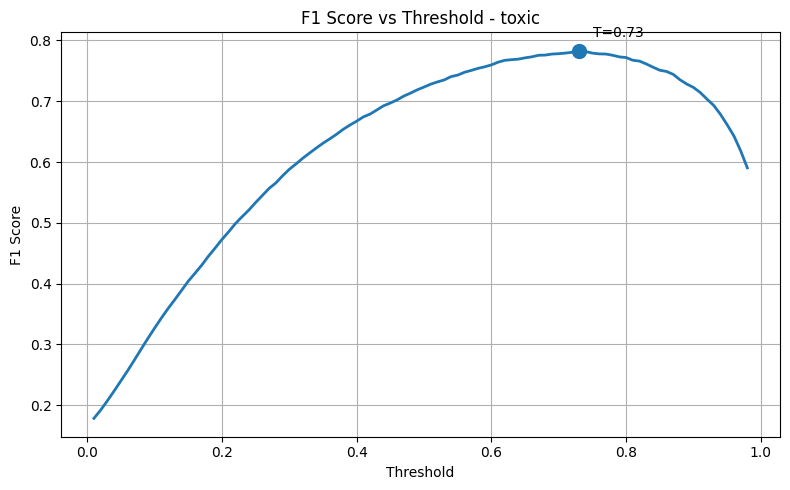

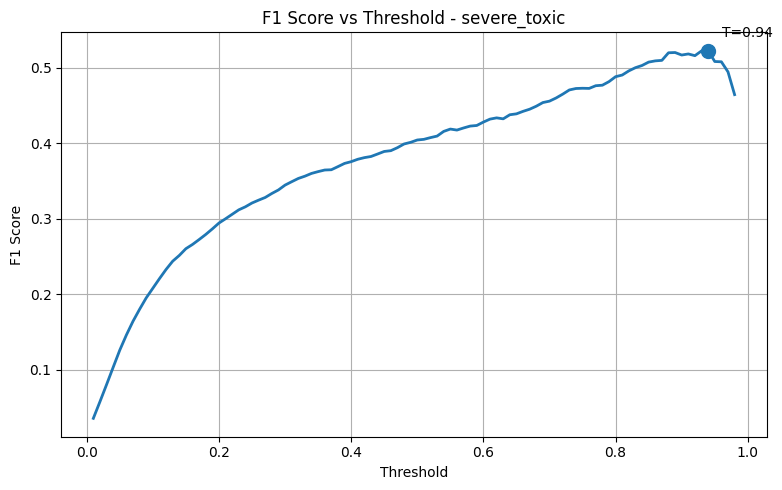

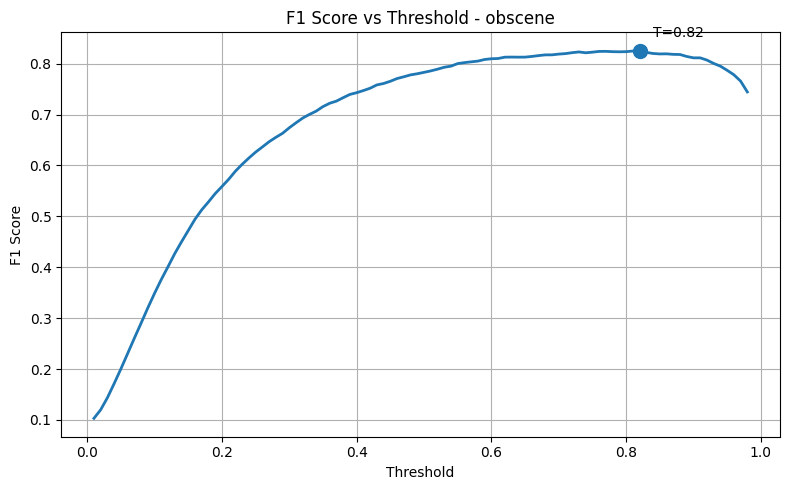

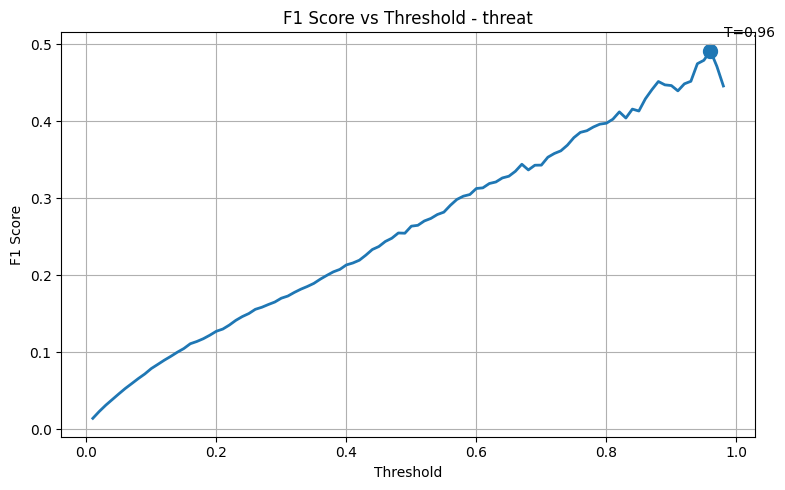

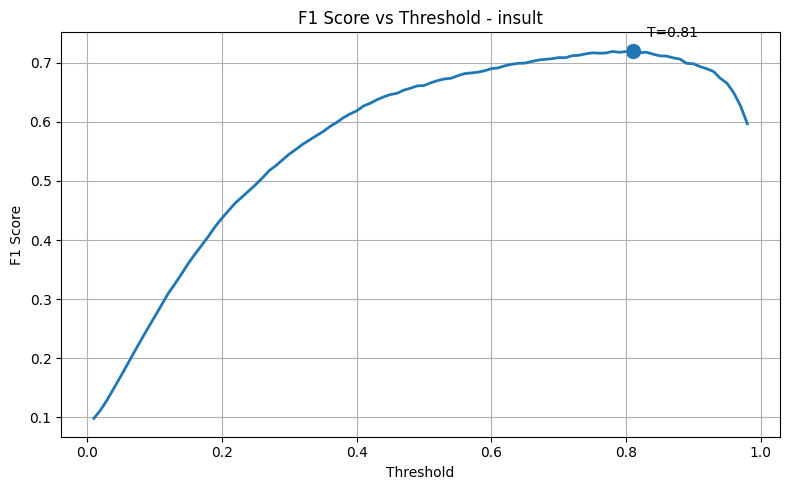

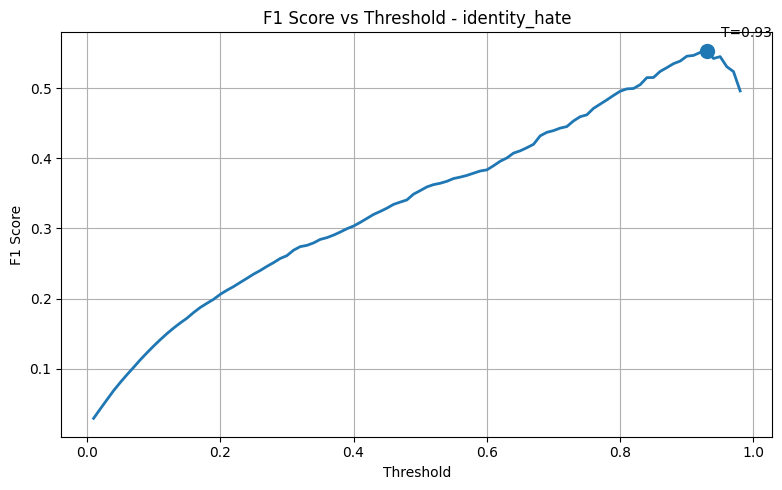

In [16]:
# 9. F1 VS THRESHOLD CURVES
# =====================================================

for i, label in enumerate(labels):

    thresholds = np.arange(
        0.01,
        0.99,
        0.01
    )

    f1_scores = []

    for threshold in thresholds:

        pred = (
            y_prob_lr[:, i] > threshold
        ).astype(int)

        f1_scores.append(
            f1_score(
                y_test.iloc[:, i],
                pred,
                zero_division=0
            )
        )

    best_idx = np.argmax(f1_scores)

    plt.figure(figsize=(8, 5))

    plt.plot(
        thresholds,
        f1_scores,
        linewidth=2
    )

    plt.scatter(
        thresholds[best_idx],
        f1_scores[best_idx],
        s=100
    )

    plt.annotate(
        f'T={thresholds[best_idx]:.2f}',
        xy=(
            thresholds[best_idx],
            f1_scores[best_idx]
        ),
        xytext=(10, 10),
        textcoords='offset points'
    )

    plt.title(
        f"F1 Score vs Threshold - {label}"
    )

    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        f"/kaggle/working/f1_threshold_{label}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

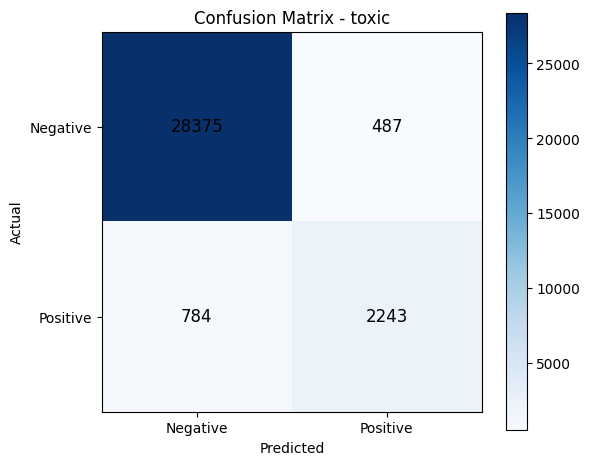

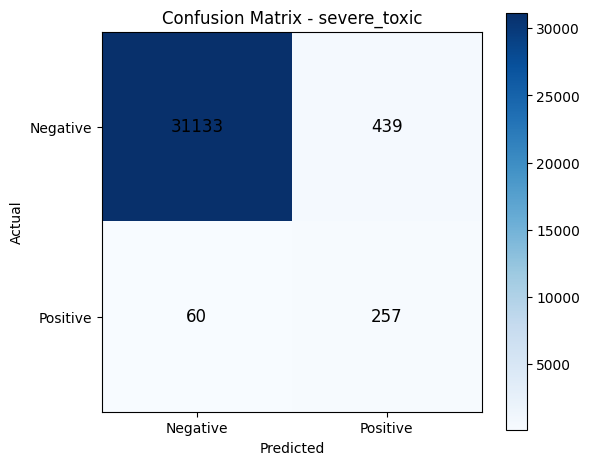

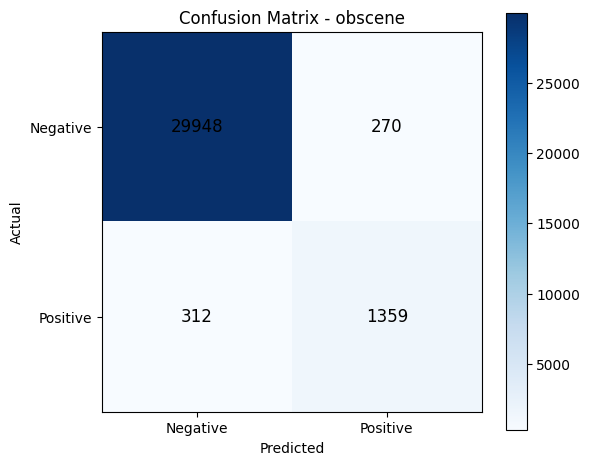

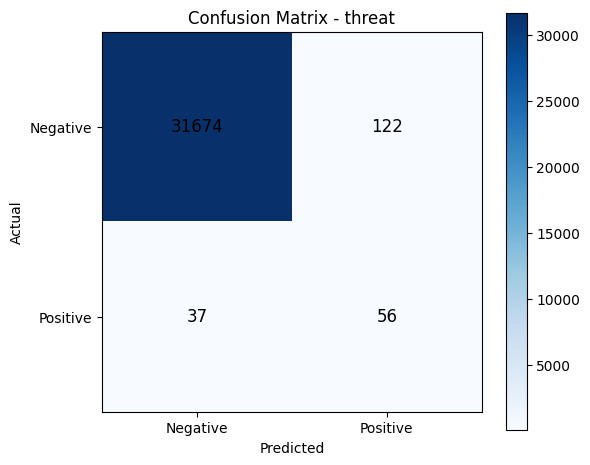

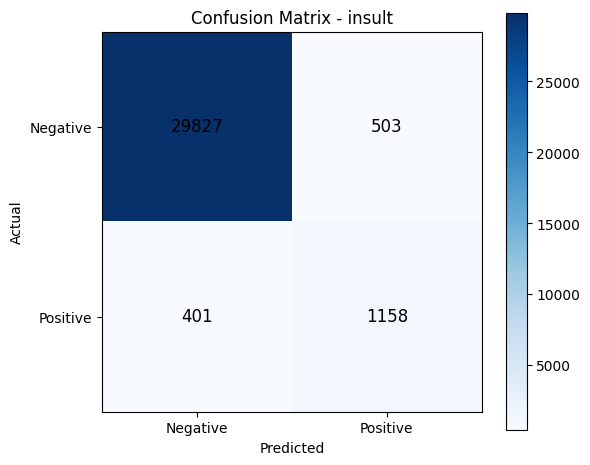

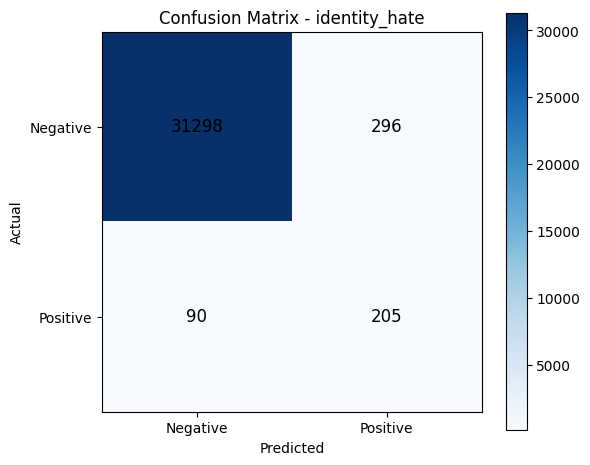

In [17]:
# 10. CONFUSION MATRICES
# =====================================================

for i, label in enumerate(labels):

    cm = confusion_matrix(
         y_test.iloc[:, i],
         y_pred_lr[:, i]
    )

    plt.figure(figsize=(6, 5))

    plt.imshow(
        cm,
        cmap="Blues"
    )

    plt.title(
        f"Confusion Matrix - {label}"
    )

    plt.colorbar()

    plt.xticks(
        [0, 1],
        ["Negative", "Positive"]
     )

    plt.yticks(
        [0, 1],
        ["Negative", "Positive"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):

            plt.text(
                c,
                r,
                str(cm[r, c]),
                ha="center",
                va="center",
                fontsize=12
            )

    plt.tight_layout()

    plt.savefig(
     f"/kaggle/working/confusion_matrix_{label}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [18]:
import joblib

joblib.dump(
    {
        "model": lr_model,
        "word_vectorizer": tfidf,
        "char_vectorizer": char_tfidf,
        "thresholds": optimal_thresholds
    },
    "/kaggle/working/logtic_regresion_pipeline.pkl"
)

print("Pipeline Saved!")

Pipeline Saved!


In [19]:
import os
print(os.listdir("/kaggle/working"))

['__notebook__.ipynb', 'confusion_matrix_severe_toxic.png', 'f1_threshold_insult.png', 'logtic_regresion_pipeline.pkl', 'f1_threshold_toxic.png', 'confusion_matrix_threat.png', 'precision_recall_f1.png', 'f1_threshold_threat.png', 'confusion_matrix_identity_hate.png', 'confusion_matrix_insult.png', 'f1_threshold_identity_hate.png', 'f1_threshold_obscene.png', 'confusion_matrix_obscene.png', 'f1_threshold_severe_toxic.png', 'confusion_matrix_toxic.png']


In [20]:
import glob

print(glob.glob("/kaggle/working/*.pkl"))

['/kaggle/working/logtic_regresion_pipeline.pkl']


In [21]:
import os

print(os.listdir("/kaggle/working"))

['__notebook__.ipynb', 'confusion_matrix_severe_toxic.png', 'f1_threshold_insult.png', 'logtic_regresion_pipeline.pkl', 'f1_threshold_toxic.png', 'confusion_matrix_threat.png', 'precision_recall_f1.png', 'f1_threshold_threat.png', 'confusion_matrix_identity_hate.png', 'confusion_matrix_insult.png', 'f1_threshold_identity_hate.png', 'f1_threshold_obscene.png', 'confusion_matrix_obscene.png', 'f1_threshold_severe_toxic.png', 'confusion_matrix_toxic.png']


In [22]:
import joblib

joblib.dump(
    {
        "model": lr_model,
        "word_vectorizer": tfidf,
        "char_vectorizer": char_tfidf,
        "thresholds": thresholds
    },
    "/kaggle/working/logistic_regression_pipeline.pkl"
)

print("Pipeline Saved!")

Pipeline Saved!


In [23]:
import os
print(os.listdir("/kaggle/working"))

['__notebook__.ipynb', 'confusion_matrix_severe_toxic.png', 'f1_threshold_insult.png', 'logtic_regresion_pipeline.pkl', 'f1_threshold_toxic.png', 'confusion_matrix_threat.png', 'precision_recall_f1.png', 'f1_threshold_threat.png', 'confusion_matrix_identity_hate.png', 'confusion_matrix_insult.png', 'logistic_regression_pipeline.pkl', 'f1_threshold_identity_hate.png', 'f1_threshold_obscene.png', 'confusion_matrix_obscene.png', 'f1_threshold_severe_toxic.png', 'confusion_matrix_toxic.png']


In [24]:
import joblib

data = joblib.load(
    "/kaggle/working/logistic_regression_pipeline.pkl"
)

model = data["model"]
tfidf = data["word_vectorizer"]
char_tfidf = data["char_vectorizer"]
thresholds = data["thresholds"]

print("Model Loaded Successfully!")

Model Loaded Successfully!
